In [35]:
import numpy as np

Exercise a) 16 possible inputs, 2 possible outputs per. Target functions are all the binary vectors of length 16.

In [36]:
from itertools import product

TARGETS = list(product([0, 1], repeat=16))

# All zeroes
print(TARGETS[0])

# All ones
print(TARGETS[-1])

# Exactly 65536 entries
print(len(TARGETS))

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)
65536


Exercise b) the kNN and memorize-or-zero classifiers

In [37]:
# Evaluate target function on input given as binary list
def eval(f, x):
    x_str = ''.join([str(s) for s in x])
    return f[int(x_str, 2)]

# Hamming distance between two binary strings
def hamming(x, y):
    distance = 0
    for i in range(len(x)):
        if x[i] != y[i]:
            distance += 1
    return distance

# k-Nearest Neighbors classifier to predict the output for input x based on the k closest entries
# in training set S given target function f
def kNN(f, S, x, k=3):
    distances = []
    for s in S:
        distance = hamming(s, x)
        distances.append((distance, s))
    distances.sort(key=lambda d: d[0])
    sum = 0
    for i in range(k):
        sum += eval(f, distances[i][1])
    return 1 if sum > k / 2 else 0

# Memorize or zero classifier for target function f, training set S, and input x
def memorize(f, S, x):
    for s in S:
        if s == x:
            return eval(f, s)
    return 0

Exercise c)

In [38]:
# Fix a training set S of size 10
INPUTS = list(product([0, 1], repeat=4))

np.random.seed(0)
indices = np.random.choice(range(16), size=10, replace=False)
indices_complement = [i for i in range(16) if i not in indices]
S = [INPUTS[i] for i in indices]
T = [INPUTS[i] for i in indices_complement]


# Compute off-training error for both classifiers across all target functions
off_training_error_3NN = np.zeros(len(TARGETS))
off_training_error_memorize = np.zeros(len(TARGETS))

for i, f in enumerate(TARGETS):
    sum_3NN = 0
    sum_mem = 0
    for x in T:
        if kNN(f, S, x) != eval(f, x):
            sum_3NN += 1
        if memorize(f, S, x) != eval(f, x):
            sum_mem += 1
    off_training_error_3NN[i] = sum_3NN / len(T)
    off_training_error_memorize[i] = sum_mem / len(T)

print("Off-training error for 3-NN:", np.mean(off_training_error_3NN))
print("Off-training error for memorize-or-zero:", np.mean(off_training_error_memorize))


Off-training error for 3-NN: 0.49999999999999994
Off-training error for memorize-or-zero: 0.49999999999999994


Exercise d)

Correlation between off-training errors: 6.938893903907228e-18


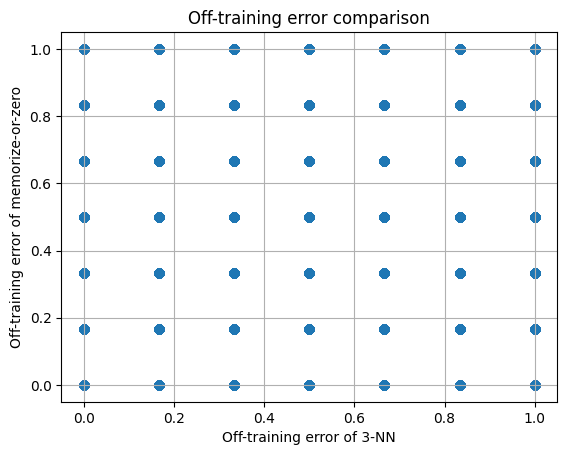

Correlation between sorted off-training errors: 0.9999999999999989


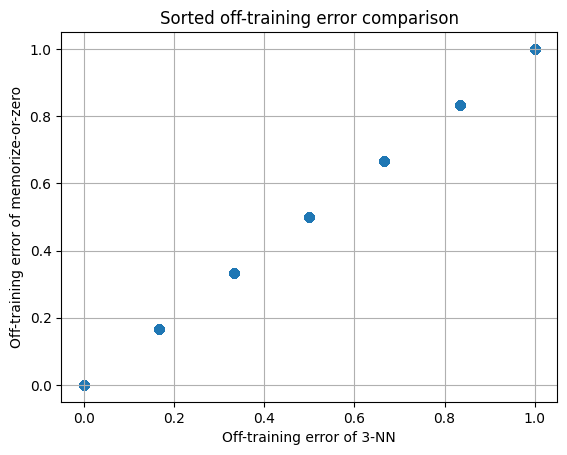

In [42]:
from scipy.stats import pearsonr

correlation, _ = pearsonr(off_training_error_3NN, off_training_error_memorize)
print("Correlation between off-training errors:", correlation)

# Scatter plot of off-training errors
import matplotlib.pyplot as plt
plt.scatter(off_training_error_3NN, off_training_error_memorize)
plt.xlabel("Off-training error of 3-NN")
plt.ylabel("Off-training error of memorize-or-zero")
plt.title("Off-training error comparison")
plt.grid()
plt.show()

ote_3NN_sorted = np.sort(off_training_error_3NN.copy())
ote_memorize_sorted = np.sort(off_training_error_memorize.copy())

correlation, _ = pearsonr(ote_3NN_sorted, ote_memorize_sorted)
print("Correlation between sorted off-training errors:", correlation)

plt.scatter(ote_3NN_sorted, ote_memorize_sorted)
plt.xlabel("Off-training error of 3-NN")
plt.ylabel("Off-training error of memorize-or-zero")
plt.title("Sorted off-training error comparison")
plt.grid()
plt.show()


Exercise f)